# ═══════════════════════════════════════
# COMPLETE OBJECT DETECTION PIPELINE
# Sign Language A-Z Detection
# ═══════════════════════════════════════
## RUN ORDER:
## CELL 1  → GPU Setup (run EVERY time)
## CELL 2  → Paths Setup (run EVERY time)
## CELL 3  → Install wget (run EVERY time)
## CELL 4  → Clone TF Models repo (runs ONCE automatically)
## CELL 5  → Install TFOD API (runs ONCE automatically)
## CELL 6  → Download Pretrained Model (runs ONCE automatically)
## CELL 7  → Create Label Map
## CELL 8  → Split Data (Initial)
## CELL 9  → Generate TF Records
## CELL 10 → Update Pipeline Config
## CELL 11 → Train Initial Model
## CELL 12 → Export Model
## CELL 13 → Test Results Per Class
## CELL 14 → Auto-Label Remaining Images
## CELL 15 → Final Split
## CELL 16 → Final Training
## CELL 17 → Export Final Model
## CELL 18 → Real-Time Webcam Detection

---
# CELL 1 — GPU Setup
### ▶️ Run EVERY time you open this notebook

In [14]:
import os
import tensorflow as tf

# Add cuDNN to PATH so TF can find it
cudnn_path = r'E:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\Lib\site-packages\nvidia\cudnn\bin'
os.environ['PATH'] = cudnn_path + ';' + os.environ['PATH']

# Allow GPU memory to grow gradually
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print('✅ GPU ready:', gpus[0])
else:
    print('⚠️  No GPU found — running on CPU')

✅ GPU ready: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


---
# CELL 2 — Paths Setup
### ▶️ Run EVERY time you open this notebook

In [15]:
import os, shutil, random

CUSTOM_MODEL_NAME     = 'my_ssd_mobnet_initial'
PRETRAINED_MODEL_NAME = 'ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8'
PRETRAINED_MODEL_URL  = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8.tar.gz'
TF_RECORD_SCRIPT_NAME = 'generate_tfrecord.py'
LABEL_MAP_NAME        = 'label_map.pbtxt'

paths = {
    'WORKSPACE_PATH':        os.path.join('Tensorflow', 'workspace'),
    'SCRIPTS_PATH':          os.path.join('Tensorflow', 'scripts'),
    'APIMODEL_PATH':         os.path.join('Tensorflow', 'models'),
    'ANNOTATION_PATH':       os.path.join('Tensorflow', 'workspace', 'annotations'),
    'IMAGE_PATH':            os.path.join('Tensorflow', 'workspace', 'images'),
    'MODEL_PATH':            os.path.join('Tensorflow', 'workspace', 'models'),
    'PRETRAINED_MODEL_PATH': os.path.join('Tensorflow', 'workspace', 'pre-trained-models'),
    'CHECKPOINT_PATH':       os.path.join('Tensorflow', 'workspace', 'models', CUSTOM_MODEL_NAME),
    'OUTPUT_PATH':           os.path.join('Tensorflow', 'workspace', 'models', CUSTOM_MODEL_NAME, 'export'),
    'PROTOC_PATH':           os.path.join('Tensorflow', 'protoc')
}

files = {
    'PIPELINE_CONFIG':  os.path.join('Tensorflow', 'workspace', 'models', CUSTOM_MODEL_NAME, 'pipeline.config'),
    'TF_RECORD_SCRIPT': os.path.join(paths['SCRIPTS_PATH'], TF_RECORD_SCRIPT_NAME),
    'LABELMAP':         os.path.join(paths['ANNOTATION_PATH'], LABEL_MAP_NAME)
}

for path in paths.values():
    os.makedirs(path, exist_ok=True)

print('✅ Paths ready!')

✅ Paths ready!


---
# CELL 3 — Install wget
### ▶️ Run EVERY time

In [16]:
if os.name == 'nt':
    !pip install wget==3.2 -q
    import wget
    print('✅ wget ready')

✅ wget ready


---
# CELL 4 — Clone TF Models Repo
### ▶️ Runs ONCE automatically (guarded)

In [17]:
if not os.path.exists(os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection')):
    !git clone https://github.com/tensorflow/models {paths['APIMODEL_PATH']}
    print('✅ TF Models repo cloned!')
else:
    print('✅ TF Models repo already exists — skipping')

✅ TF Models repo already exists — skipping


---
# CELL 5 — Install TFOD API
### ▶️ Runs ONCE automatically (flag guarded)

In [18]:
INSTALL_FLAG = 'Tensorflow/.tfod_installed'

if not os.path.exists(INSTALL_FLAG):
    print('[1/6] Downloading protoc...')
    import wget
    url = 'https://github.com/protocolbuffers/protobuf/releases/download/v3.15.6/protoc-3.15.6-win64.zip'
    wget.download(url)
    !move protoc-3.15.6-win64.zip {paths['PROTOC_PATH']}
    !cd {paths['PROTOC_PATH']} && tar -xf protoc-3.15.6-win64.zip
    os.environ['PATH'] += os.pathsep + os.path.abspath(os.path.join(paths['PROTOC_PATH'], 'bin'))
    print('\n[2/6] Compiling protos...')
    !cd Tensorflow/models/research && protoc object_detection/protos/*.proto --python_out=.
    print('\n[3/6] Installing object detection API...')
    !cd Tensorflow/models/research && copy object_detection\\packages\\tf2\\setup.py setup.py && python setup.py build && python setup.py install
    print('\n[4/6] Installing slim...')
    !cd Tensorflow/models/research/slim && pip install -e .
    print('\n[5/6] Pinning tf-models-official...')
    !pip install tf-models-official==2.10.1 --force-reinstall -q
    print('\n[6/6] Installing scipy...')
    !pip install scipy==1.11.4 -q
    open(INSTALL_FLAG, 'w').close()
    print('\n✅ Installation complete!')
else:
    print('✅ Already installed — skipping')

✅ Already installed — skipping


---
# CELL 6 — Download Pretrained Model
### ▶️ Runs ONCE automatically (guarded)

In [19]:
import wget
pretrained_dir = os.path.join(paths['PRETRAINED_MODEL_PATH'], PRETRAINED_MODEL_NAME)

if not os.path.exists(pretrained_dir):
    print('Downloading pretrained model (~30MB)...')
    filename = wget.download(PRETRAINED_MODEL_URL)
    !move {filename} {paths['PRETRAINED_MODEL_PATH']}
    !cd {paths['PRETRAINED_MODEL_PATH']} && tar -zxvf {PRETRAINED_MODEL_NAME+'.tar.gz'}
    print('\n✅ Pretrained model downloaded!')
else:
    print('✅ Pretrained model already exists — skipping')

✅ Pretrained model already exists — skipping


---
# CELL 7 — Create Label Map
### ⬇️ Change TEST_CLASSES to match what you are training
### For class A only: ['A'] | For A,B,C: ['A','B','C'] | For all: list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

In [ ]:
# ⬇️ CHANGE THIS
# TEST_CLASSES = ['A']
TEST_CLASSES = [c for c in 'ABCDEFGHIKLMNOPQRSTUVWXY']  # excludes J and Z

with open(files['LABELMAP'], 'w') as f:
    for i, label in enumerate(TEST_CLASSES):
        f.write('item {\n')
        f.write(f'  id: {i + 1}\n')
        f.write(f"  name: '{label}'\n")
        f.write('}\n\n')

print(f'✅ Label map created with {len(TEST_CLASSES)} classes:')
print(open(files['LABELMAP']).read())

✅ Label map created with 1 classes:
item {
  id: 1
  name: 'A'
}




---
# CELL 8 — Split Data (Initial: Manually Labeled Only)
### Run AFTER labeling 20+ images
### ⬇️ TEST_CLASSES must match Cell 7

In [ ]:
# Check all classes have 20+ labeled before splitting
print('Checking labeling progress...')
not_ready = []
for label in TEST_CLASSES:
    d = os.path.join('Tensorflow', 'workspace', 'images', 'collectedimages', label)
    if not os.path.exists(d):
        not_ready.append(f'{label} (folder missing)')
        continue
    imgs    = [f for f in os.listdir(d) if f.endswith('.jpg')]
    labeled = [f for f in imgs if os.path.exists(os.path.join(d, f.replace('.jpg','.xml')))]
    if len(labeled) < 20:
        not_ready.append(f'{label} (only {len(labeled)} labeled)')

if not_ready:
    print('⚠️  These classes are NOT ready:')
    for c in not_ready: print(f'   → {c}')
    print('\nLabel at least 20 images per class before splitting!')
else:
    print('✅ All classes ready! Proceeding with split...')

In [21]:
IMAGES_PATH = os.path.join('Tensorflow', 'workspace', 'images', 'collectedimages')
TRAIN_LABEL = os.path.join('Tensorflow', 'workspace', 'images', 'train_label')
TEST_LABEL  = os.path.join('Tensorflow', 'workspace', 'images', 'test_label')

# Clear old split to avoid duplicates
if os.path.exists(TRAIN_LABEL): shutil.rmtree(TRAIN_LABEL)
if os.path.exists(TEST_LABEL):  shutil.rmtree(TEST_LABEL)
os.makedirs(TRAIN_LABEL, exist_ok=True)
os.makedirs(TEST_LABEL,  exist_ok=True)

total_train = total_test = 0
for label in TEST_CLASSES:
    d = os.path.join(IMAGES_PATH, label)
    if not os.path.exists(d): continue
    labeled = [f for f in os.listdir(d) if f.endswith('.jpg') and
               os.path.exists(os.path.join(d, f.replace('.jpg', '.xml')))]
    if not labeled:
        print(f'[SKIP] {label} — no labeled images'); continue
    random.shuffle(labeled)
    sp = int(0.8 * len(labeled))
    for img in labeled[:sp]:
        shutil.copy(os.path.join(d, img), TRAIN_LABEL)
        shutil.copy(os.path.join(d, img.replace('.jpg', '.xml')), TRAIN_LABEL)
    for img in labeled[sp:]:
        shutil.copy(os.path.join(d, img), TEST_LABEL)
        shutil.copy(os.path.join(d, img.replace('.jpg', '.xml')), TEST_LABEL)
    total_train += len(labeled[:sp])
    total_test  += len(labeled[sp:])
    print(f'[OK] {label}: {len(labeled[:sp])} train, {len(labeled[sp:])} test')

print(f'\n✅ Split done → train_label: {total_train}, test_label: {total_test}')

[OK] A: 16 train, 4 test

✅ Split done → train_label: 16, test_label: 4


---
# CELL 9 — Generate TF Records

In [22]:
# Download generate_tfrecord.py if not exists
if not os.path.exists(files['TF_RECORD_SCRIPT']):
    import wget
    wget.download(
        'https://tensorflow-object-detection-api-tutorial.readthedocs.io/en/latest/_downloads/da4babe668a8afb093cc7776d7e630f3/generate_tfrecord.py',
        files['TF_RECORD_SCRIPT']
    )
    print('✅ generate_tfrecord.py downloaded!')

!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'], 'train_label')} -l {files['LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'train.record')}
!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'], 'test_label')}  -l {files['LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'test.record')}
print('\n✅ TF Records created!')

Successfully created the TFRecord file: Tensorflow\workspace\annotations\train.record


e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.13). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSIST

Successfully created the TFRecord file: Tensorflow\workspace\annotations\test.record

✅ TF Records created!


e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.13). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSIST

---
# CELL 10 — Update Pipeline Config

In [ ]:
import tensorflow as tf
from object_detection.utils import config_util
from object_detection.protos import pipeline_pb2
from google.protobuf import text_format

# ── How many classes are you training now? ──────
# Change this to match your TEST_CLASSES
NUM_CLASSES = len(TEST_CLASSES)

# ── Which checkpoint to fine-tune from? ─────────
# Use your latest checkpoint (ckpt-8 is your best so far)
FINETUNE_CHECKPOINT = os.path.join(
    'Tensorflow', 'workspace', 'models',
    'my_ssd_mobnet_initial', 'ckpt-8')  # update the latest checkpoint here

# ── Copy pretrained pipeline config ─────────────
src = os.path.join(paths['PRETRAINED_MODEL_PATH'], PRETRAINED_MODEL_NAME, 'pipeline.config')
!copy {src} {paths['CHECKPOINT_PATH']}

# ── Load config ──────────────────────────────────
pipeline_config = pipeline_pb2.TrainEvalPipelineConfig()
with tf.io.gfile.GFile(files['PIPELINE_CONFIG'], 'r') as f:
    text_format.Merge(f.read(), pipeline_config)

# ── Update ALL values ────────────────────────────
pipeline_config.model.ssd.num_classes                                                                   = NUM_CLASSES
pipeline_config.train_config.batch_size                                                                 = 2
pipeline_config.train_config.num_steps                                                                  = 2000
pipeline_config.train_config.fine_tune_checkpoint                                                       = FINETUNE_CHECKPOINT
pipeline_config.train_config.fine_tune_checkpoint_type                                                  = 'detection'
pipeline_config.train_config.optimizer.momentum_optimizer.learning_rate.cosine_decay_learning_rate.total_steps  = 2000
pipeline_config.train_config.optimizer.momentum_optimizer.learning_rate.cosine_decay_learning_rate.warmup_steps = 100
pipeline_config.train_input_reader.label_map_path                                                       = files['LABELMAP']
pipeline_config.train_input_reader.tf_record_input_reader.input_path[:]                                 = [os.path.join(paths['ANNOTATION_PATH'], 'train.record')]
pipeline_config.eval_input_reader[0].label_map_path                                                     = files['LABELMAP']
pipeline_config.eval_input_reader[0].tf_record_input_reader.input_path[:]                               = [os.path.join(paths['ANNOTATION_PATH'], 'test.record')]

# ── Save config ──────────────────────────────────
config_text = text_format.MessageToString(pipeline_config)
with tf.io.gfile.GFile(files['PIPELINE_CONFIG'], 'wb') as f:
    f.write(config_text)

print('✅ Pipeline config updated!')
print(f'   Classes          : {TEST_CLASSES}')
print(f'   Num classes      : {NUM_CLASSES}')
print(f'   Fine-tune from   : {FINETUNE_CHECKPOINT}')
print(f'   Batch size       : 2')
print(f'   Steps            : 2000')

        1 file(s) copied.
✅ Pipeline config updated!
   Classes    : ['A']
   Batch size : 2
   Num steps  : 2000
   Checkpoint : Tensorflow\workspace\pre-trained-models\ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8\checkpoint\ckpt-0
   Train record: ['Tensorflow\\workspace\\annotations\\train.record']


---
# CELL 11 — Train Initial Model
### 2000 steps — quick training to power auto-labeling
### Watch the loss — it should go below 1.0

In [28]:
import re

model_lib_path = r'E:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\object_detection\model_lib_v2.py'

with open(model_lib_path, 'r') as f:
    content = f.read()

# Fix 1 — disable image summaries
content = content.replace(
    'if False:  # disabled to fix JIT compilation error',
    'if False:  # disabled'
)
content = content.replace(
    'if record_summaries:',
    'if False:  # disabled'
)

# Fix 2 — disable the lambda that causes FloorMod JIT error
content = content.replace(
    'lambda: global_step % num_steps_per_iteration == 0)',
    'True)'
)

with open(model_lib_path, 'w') as f:
    f.write(content)

print('✅ model_lib_v2.py patched — all summaries disabled')

# Verify patch
with open(model_lib_path, 'r') as f:
    lines = f.readlines()
for i, line in enumerate(lines):
    if 'disabled' in line or 'True)' in line and 'num_steps' in lines[max(0,i-1)]:
        print(f'Line {i+1}: {line.rstrip()}')

✅ model_lib_v2.py patched — all summaries disabled
Line 629:           if False:  # disabled


In [ ]:
wrapper_code = f"""
import sys, os

# Fix cuDNN path
cudnn_path = r'E:\\Study\\Projects\\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\\ObjEnv\\Lib\\site-packages\\nvidia\\cudnn\\bin'
os.environ['PATH'] = cudnn_path + ';' + os.environ.get('PATH', '')

# Fix libdevice / disable XLA JIT
os.environ['TF_XLA_FLAGS']          = '--tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS']             = '--xla_gpu_cuda_data_dir=C:\\\\Program Files\\\\NVIDIA GPU Computing Toolkit\\\\CUDA\\\\v13.2'
os.environ['TF_CPP_MIN_LOG_LEVEL']  = '2'
os.environ['CUDA_DIR']              = 'C:\\\\Program Files\\\\NVIDIA GPU Computing Toolkit\\\\CUDA\\\\v13.2'

sys.argv = [
    'model_main_tf2.py',
    '--model_dir={paths['CHECKPOINT_PATH']}',
    '--pipeline_config_path={files['PIPELINE_CONFIG']}',
    '--num_train_steps=3000',
    '--alsologtostderr'
]
with open(r'Tensorflow/models/research/object_detection/model_main_tf2.py') as f:
    exec(compile(f.read(), r'Tensorflow/models/research/object_detection/model_main_tf2.py', 'exec'))
"""

with open('train_wrapper.py', 'w') as f:
    f.write(wrapper_code)

print('▶️  Starting initial training (2000 steps)...')
print('   Loss will print every 50 steps\\n')
!python train_wrapper.py

▶️  Starting initial training (2000 steps)...
   Loss will print every 50 steps\n


e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.13). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSIST

---
# CELL 12 — Export Initial Model

In [30]:
FREEZE_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'exporter_main_v2.py')
!python {FREEZE_SCRIPT} \
    --input_type=image_tensor \
    --pipeline_config_path={files['PIPELINE_CONFIG']} \
    --trained_checkpoint_dir={paths['CHECKPOINT_PATH']} \
    --output_directory={paths['OUTPUT_PATH']}
print('\n✅ Model exported to:', paths['OUTPUT_PATH'])


✅ Model exported to: Tensorflow\workspace\models\my_ssd_mobnet_initial\export


e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.13). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\ObjEnv\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
e:\Study\Projects\REAL-TIME OBJECT DETECTION FOR ASSIST

---
# CELL 13 — Test Results Per Class
### ⬇️ Change TEST_CLASS to check any class: 'A', 'B', 'C' etc.
### Controls: Any key = next image | Q = stop

✅ Model loaded!
Testing class A: 4 images

  A.4b80d095-5c35-11f1-9be3-2811a889ff48.jpg: [('A', 0.93)]


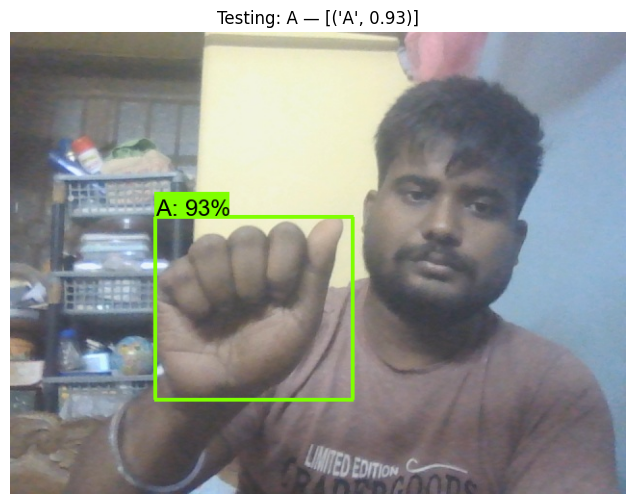

  A.5a9a077f-177a-11ee-83dd-2811a889ff48.jpg: [('A', 0.99)]


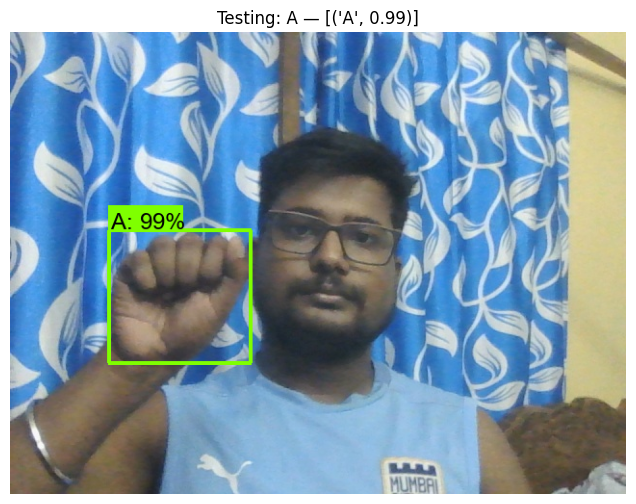

  A.6950562c-177a-11ee-bfd0-2811a889ff48.jpg: [('A', 0.99)]


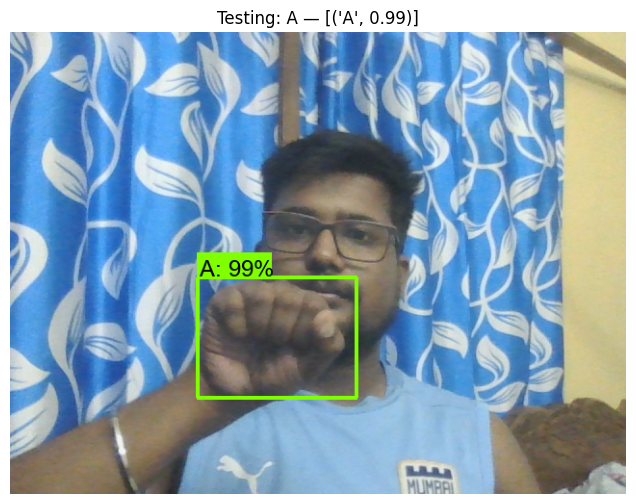

  A.97733499-177a-11ee-b4db-2811a889ff48.jpg: [('A', 0.99)]


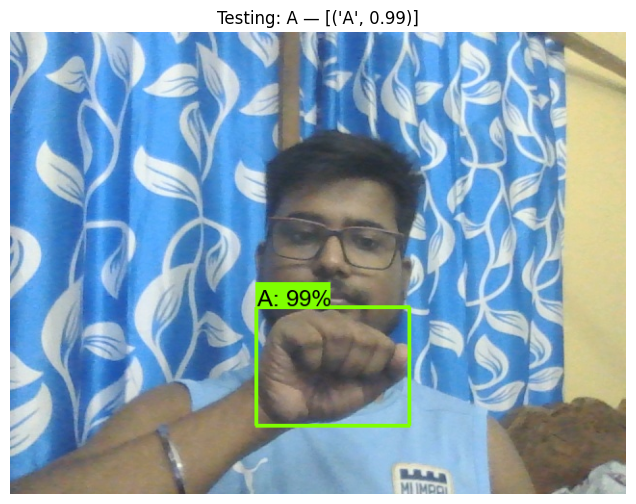


✅ Testing class A complete!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image as PILImage
import io
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils

# Load model
detect_fn      = tf.saved_model.load(os.path.join(paths['OUTPUT_PATH'], 'saved_model'))
category_index = label_map_util.create_category_index_from_labelmap(files['LABELMAP'])
print('✅ Model loaded!')

TEST_LABEL_DIR = os.path.join(paths['IMAGE_PATH'], 'test_label')

# ── Test ALL classes ──────────────────────────────
results_summary = {}

for TEST_CLASS in TEST_CLASSES:
    images = [f for f in os.listdir(TEST_LABEL_DIR)
              if f.startswith(TEST_CLASS + '.') and f.endswith('.jpg')]

    if not images:
        print(f'\n[{TEST_CLASS}] ⚠️  No test images found — skipping')
        continue

    print(f'\n{"="*50}')
    print(f'  CLASS: {TEST_CLASS} — {len(images)} test images')
    print(f'{"="*50}')

    class_correct = 0
    class_scores  = []
    fig, axes     = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    if len(images) == 1:
        axes = [axes]

    for idx, img_file in enumerate(images):
        img_path     = os.path.join(TEST_LABEL_DIR, img_file)
        img          = cv2.imread(img_path)
        image_np     = np.array(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, 0), dtype=tf.uint8)
        detections   = detect_fn(input_tensor)
        num_det      = int(detections.pop('num_detections'))
        detections   = {k: v[0, :num_det].numpy() for k, v in detections.items()}
        detections['num_detections']    = num_det
        detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

        image_with_boxes = image_np.copy()
        viz_utils.visualize_boxes_and_labels_on_image_array(
            image_with_boxes,
            detections['detection_boxes'],
            detections['detection_classes'],
            detections['detection_scores'],
            category_index,
            use_normalized_coordinates=True,
            max_boxes_to_draw=3,
            min_score_thresh=0.5,
            agnostic_mode=False)

        top = [(category_index.get(c, {}).get('name', str(c)), round(float(s), 2))
               for c, s in zip(detections['detection_classes'], detections['detection_scores'])
               if s >= 0.5]

        # Check if correct
        if top and top[0][0] == TEST_CLASS:
            class_correct += 1
            class_scores.append(top[0][1])
            status = '✅'
        elif top:
            status = f'❌ got {top[0][0]}'
        else:
            status = '⚠️  no detect'

        print(f'  {img_file[:30]}: {top if top else "No detection"} {status}')

        # Show in grid
        axes[idx].imshow(image_with_boxes)
        axes[idx].set_title(f'{top}\n{status}', fontsize=8)
        axes[idx].axis('off')

    # Class accuracy
    accuracy = round(class_correct / len(images) * 100, 1)
    avg_score = round(sum(class_scores) / len(class_scores), 2) if class_scores else 0
    results_summary[TEST_CLASS] = {'accuracy': accuracy, 'avg_score': avg_score}

    grade = '✅' if accuracy >= 80 else '⚠️ ' if accuracy >= 50 else '❌'
    print(f'\n  {grade} {TEST_CLASS}: {class_correct}/{len(images)} correct ({accuracy}%) | avg score: {avg_score}')

    plt.suptitle(f'Class {TEST_CLASS} — {accuracy}% accuracy', fontsize=12)
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    display(PILImage.open(buf))
    plt.close()

# ── Final Summary Table ───────────────────────────
print(f'\n{"="*50}')
print(f'  FINAL RESULTS SUMMARY')
print(f'{"="*50}')
print(f'  {"Class":<8} {"Accuracy":<12} {"Avg Score":<12} Status')
print(f'{"="*50}')

for cls, res in results_summary.items():
    grade = '✅' if res['accuracy'] >= 80 else '⚠️ ' if res['accuracy'] >= 50 else '❌'
    print(f'  {grade} {cls:<6} {str(res["accuracy"])+"%":<12} {res["avg_score"]:<12}')

overall = round(sum(r['accuracy'] for r in results_summary.values()) / len(results_summary), 1)
print(f'{"="*50}')
print(f'  Overall accuracy: {overall}%')
print(f'{"="*50}')

---
# CELL 14 — Auto-Label Remaining Images
### Run AFTER initial training and export
### ⬇️ Change AUTO_LABEL_CLASSES to match your classes
### Already labeled images are SKIPPED automatically ✅

In [ ]:
import re, json
import numpy as np
from PIL import Image
import xml.etree.ElementTree as ET
from xml.dom import minidom

IMAGES_PATH        = os.path.join('Tensorflow', 'workspace', 'images', 'collectedimages')
SAVED_MODEL        = os.path.join(paths['OUTPUT_PATH'], 'saved_model')
CONFIDENCE         = 0.5

# ⬇️ CHANGE THIS: ['A'] for one class, list('ABCDEFGHIJKLMNOPQRSTUVWXYZ') for all
# AUTO_LABEL_CLASSES = ['A']
AUTO_LABEL_CLASSES = [c for c in 'ABCDEFGHIKLMNOPQRSTUVWXY']

def parse_label_map(path):
    lm = {}
    content = open(path).read()
    for item in re.findall(r'item\s*\{([^}]*)\}', content):
        id_m   = re.search(r'id\s*:\s*(\d+)', item)
        name_m = re.search(r"name\s*:\s*'([^']*)'" , item)
        if id_m and name_m: lm[int(id_m.group(1))] = name_m.group(1)
    return lm

def create_xml(filename, folder, w, h, dets):
    ann = ET.Element('annotation')
    ET.SubElement(ann, 'folder').text   = folder
    ET.SubElement(ann, 'filename').text = filename
    sz = ET.SubElement(ann, 'size')
    ET.SubElement(sz, 'width').text  = str(w)
    ET.SubElement(sz, 'height').text = str(h)
    ET.SubElement(sz, 'depth').text  = '3'
    for d in dets:
        obj = ET.SubElement(ann, 'object')
        ET.SubElement(obj, 'name').text      = d['class']
        ET.SubElement(obj, 'pose').text      = 'Unspecified'
        ET.SubElement(obj, 'truncated').text = '0'
        ET.SubElement(obj, 'difficult').text = '0'
        bb = ET.SubElement(obj, 'bndbox')
        ET.SubElement(bb, 'xmin').text = str(d['xmin'])
        ET.SubElement(bb, 'ymin').text = str(d['ymin'])
        ET.SubElement(bb, 'xmax').text = str(d['xmax'])
        ET.SubElement(bb, 'ymax').text = str(d['ymax'])
    return minidom.parseString(ET.tostring(ann)).toprettyxml(indent='   ')

print('[INFO] Loading model...')
infer     = tf.saved_model.load(SAVED_MODEL).signatures['serving_default']
label_map = parse_label_map(files['LABELMAP'])
print('[INFO] Model loaded!\n')

manual_review = []; total_labeled = 0; total_skipped = 0

for label in AUTO_LABEL_CLASSES:
    class_dir = os.path.join(IMAGES_PATH, label)
    if not os.path.exists(class_dir): continue
    images = [f for f in os.listdir(class_dir) if f.endswith('.jpg')]
    print(f'[{label}] {len(images)} images')
    for img_file in images:
        img_path = os.path.join(class_dir, img_file)
        xml_path = os.path.join(class_dir, img_file.replace('.jpg', '.xml'))
        if os.path.exists(xml_path):   # ✅ Skip already labeled
            total_skipped += 1; continue
        try:
            img    = Image.open(img_path).convert('RGB')
            w, h   = img.size
            tensor = tf.convert_to_tensor(np.array(img), dtype=tf.uint8)[tf.newaxis, ...]
            dets   = infer(tensor)
            boxes  = dets['detection_boxes'].numpy()[0]
            scores = dets['detection_scores'].numpy()[0]
            clss   = dets['detection_classes'].numpy()[0].astype(int)
            valid  = []
            for box, score, cls in zip(boxes, scores, clss):
                if score < CONFIDENCE: continue
                ymin, xmin, ymax, xmax = box
                valid.append({'class': label_map.get(cls, label), 'score': float(score),
                              'xmin': int(xmin*w), 'ymin': int(ymin*h),
                              'xmax': int(xmax*w), 'ymax': int(ymax*h)})
            if not valid:
                manual_review.append({'image': img_path, 'reason': 'no confident detection'})
                print(f'  ⚠️  {img_file} → manual review'); continue
            with open(xml_path, 'w') as f:
                f.write(create_xml(img_file, label, w, h, valid))
            total_labeled += 1
            print(f'  ✅ {img_file} (score: {valid[0]["score"]:.2f})')
        except Exception as e:
            print(f'  ❌ {img_file}: {e}')
            manual_review.append({'image': img_path, 'reason': str(e)})

with open('manual_review.json', 'w') as f:
    json.dump(manual_review, f, indent=2)

print(f'\n{"="*50}')
print(f'✅ Auto-labeled  : {total_labeled}')
print(f'⏭️  Skipped       : {total_skipped} (already labeled)')
print(f'⚠️  Manual review : {len(manual_review)} → manual_review.json')
print(f'{"="*50}')

[INFO] Loading model...
[INFO] Model loaded!

[A] 51 images
  ✅ A.407ae9d1-5c35-11f1-8367-2811a889ff48.jpg (score: 0.99)
  ✅ A.41b47f07-5c35-11f1-8732-2811a889ff48.jpg (score: 0.98)
  ✅ A.42ef22a5-5c35-11f1-ad9b-2811a889ff48.jpg (score: 0.94)
  ✅ A.4423c652-5c35-11f1-b72f-2811a889ff48.jpg (score: 0.96)
  ✅ A.455e8ee9-5c35-11f1-b43d-2811a889ff48.jpg (score: 0.98)
  ✅ A.4697e787-5c35-11f1-ba0b-2811a889ff48.jpg (score: 0.97)
  ✅ A.47d36155-5c35-11f1-b73e-2811a889ff48.jpg (score: 0.82)
  ✅ A.5062fef3-5c35-11f1-89ae-2811a889ff48.jpg (score: 0.95)
  ✅ A.51974baa-5c35-11f1-ae0b-2811a889ff48.jpg (score: 0.98)
  ✅ A.52cf8840-5c35-11f1-ab68-2811a889ff48.jpg (score: 0.95)
  ✅ A.54074101-5c35-11f1-a85e-2811a889ff48.jpg (score: 0.76)
  ✅ A.553b53a1-5c35-11f1-88fd-2811a889ff48.jpg (score: 0.99)
  ✅ A.57a430d6-5c35-11f1-ba00-2811a889ff48.jpg (score: 0.97)
  ✅ A.58deecaf-5c35-11f1-bd0b-2811a889ff48.jpg (score: 0.94)
  ✅ A.5b48d38c-5c35-11f1-8ba9-2811a889ff48.jpg (score: 0.96)
  ✅ A.5c7d0267-5c35-11f1-

---
# CELL 15 — Final Split (All Labeled Images)
### Run AFTER auto-labeling is complete
### ⬇️ Change FINAL_CLASSES to your full class list

In [36]:
IMAGES_PATH  = os.path.join('Tensorflow', 'workspace', 'images', 'collectedimages')
TRAIN_FINAL  = os.path.join('Tensorflow', 'workspace', 'images', 'train')
TEST_FINAL   = os.path.join('Tensorflow', 'workspace', 'images', 'test')

# ⬇️ CHANGE THIS to your full class list
FINAL_CLASSES = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

# Clear old folders
if os.path.exists(TRAIN_FINAL): shutil.rmtree(TRAIN_FINAL)
if os.path.exists(TEST_FINAL):  shutil.rmtree(TEST_FINAL)
os.makedirs(TRAIN_FINAL, exist_ok=True)
os.makedirs(TEST_FINAL,  exist_ok=True)

total_train = total_test = 0
for label in FINAL_CLASSES:
    d = os.path.join(IMAGES_PATH, label)
    if not os.path.exists(d): continue
    all_labeled = [f for f in os.listdir(d) if f.endswith('.jpg') and
                   os.path.exists(os.path.join(d, f.replace('.jpg', '.xml')))]
    if not all_labeled:
        print(f'[SKIP] {label}'); continue
    random.shuffle(all_labeled)
    sp = int(0.8 * len(all_labeled))
    for img in all_labeled[:sp]:
        shutil.copy(os.path.join(d, img), TRAIN_FINAL)
        shutil.copy(os.path.join(d, img.replace('.jpg', '.xml')), TRAIN_FINAL)
    for img in all_labeled[sp:]:
        shutil.copy(os.path.join(d, img), TEST_FINAL)
        shutil.copy(os.path.join(d, img.replace('.jpg', '.xml')), TEST_FINAL)
    total_train += len(all_labeled[:sp])
    total_test  += len(all_labeled[sp:])
    print(f'[OK] {label}: {len(all_labeled[:sp])} train, {len(all_labeled[sp:])} test')

print(f'\n✅ Final split → train: {total_train}, test: {total_test}')

[OK] A: 40 train, 11 test
[OK] B: 14 train, 4 test
[OK] C: 9 train, 3 test
[OK] D: 13 train, 4 test
[OK] E: 15 train, 4 test
[OK] F: 15 train, 4 test
[OK] G: 12 train, 4 test
[OK] H: 11 train, 3 test
[OK] I: 12 train, 4 test
[OK] J: 12 train, 4 test
[OK] K: 12 train, 3 test
[OK] L: 12 train, 4 test
[OK] M: 14 train, 4 test
[OK] N: 13 train, 4 test
[OK] O: 13 train, 4 test
[OK] P: 13 train, 4 test
[OK] Q: 10 train, 3 test
[OK] R: 11 train, 3 test
[OK] S: 10 train, 3 test
[OK] T: 12 train, 3 test
[OK] U: 10 train, 3 test
[OK] V: 13 train, 4 test
[OK] W: 13 train, 4 test
[OK] X: 10 train, 3 test
[OK] Y: 11 train, 3 test
[OK] Z: 12 train, 4 test

✅ Final split → train: 342, test: 101


---
# CELL 16 — Final Training (All Classes)
### 10000 steps — full training

In [ ]:
# Update to final model name
CUSTOM_MODEL_NAME        = 'my_ssd_mobnet_final'
paths['CHECKPOINT_PATH'] = os.path.join('Tensorflow', 'workspace', 'models', CUSTOM_MODEL_NAME)
paths['OUTPUT_PATH']     = os.path.join('Tensorflow', 'workspace', 'models', CUSTOM_MODEL_NAME, 'export')
files['PIPELINE_CONFIG'] = os.path.join('Tensorflow', 'workspace', 'models', CUSTOM_MODEL_NAME, 'pipeline.config')
os.makedirs(paths['CHECKPOINT_PATH'], exist_ok=True)

# Update label map for all 26 classes
FINAL_CLASSES = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
with open(files['LABELMAP'], 'w') as f:
    for i, label in enumerate(FINAL_CLASSES):
        f.write('item {\n')
        f.write(f'  id: {i + 1}\n')
        f.write(f"  name: '{label}'\n")
        f.write('}\n\n')
print('✅ Label map updated for all 26 classes!')

# Generate final TF Records
!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'], 'train')} -l {files['LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'train.record')}
!python {files['TF_RECORD_SCRIPT']} -x {os.path.join(paths['IMAGE_PATH'], 'test')}  -l {files['LABELMAP']} -o {os.path.join(paths['ANNOTATION_PATH'], 'test.record')}
print('✅ Final TF Records created!')

# Copy and update pipeline config
src = os.path.join(paths['PRETRAINED_MODEL_PATH'], 'ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8', 'pipeline.config')
!copy {src} {paths['CHECKPOINT_PATH']}

pipeline_config = pipeline_pb2.TrainEvalPipelineConfig()
with tf.io.gfile.GFile(files['PIPELINE_CONFIG'], 'r') as f:
    text_format.Merge(f.read(), pipeline_config)

pipeline_config.model.ssd.num_classes                                              = len(FINAL_CLASSES)
pipeline_config.train_config.batch_size                                            = 2
pipeline_config.train_config.fine_tune_checkpoint                                  = os.path.join(paths['PRETRAINED_MODEL_PATH'], 'ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8', 'checkpoint', 'ckpt-0')
pipeline_config.train_config.fine_tune_checkpoint_type                             = 'detection'
pipeline_config.train_input_reader.label_map_path                                  = files['LABELMAP']
pipeline_config.train_input_reader.tf_record_input_reader.input_path[:]            = [os.path.join(paths['ANNOTATION_PATH'], 'train.record')]
pipeline_config.eval_input_reader[0].label_map_path                                = files['LABELMAP']
pipeline_config.eval_input_reader[0].tf_record_input_reader.input_path[:]          = [os.path.join(paths['ANNOTATION_PATH'], 'test.record')]

config_text = text_format.MessageToString(pipeline_config)
with tf.io.gfile.GFile(files['PIPELINE_CONFIG'], 'wb') as f:
    f.write(config_text)
print('✅ Final pipeline config updated!')

# Write training wrapper
wrapper_code = f"""
import sys, os
cudnn_path = r'E:\\Study\\Projects\\REAL-TIME OBJECT DETECTION FOR ASSISTING COMMUNICATION IN NON-VERBAL INDIVIDUALS\\ObjEnv\\Lib\\site-packages\\nvidia\\cudnn\\bin'
os.environ['PATH'] = cudnn_path + ';' + os.environ.get('PATH', '')
sys.argv = [
    'model_main_tf2.py',
    '--model_dir={paths['CHECKPOINT_PATH']}',
    '--pipeline_config_path={files['PIPELINE_CONFIG']}',
    '--num_train_steps=10000'
]
with open(r'Tensorflow/models/research/object_detection/model_main_tf2.py') as f:
    exec(compile(f.read(), r'Tensorflow/models/research/object_detection/model_main_tf2.py', 'exec'))
"""
with open('train_wrapper.py', 'w') as f:
    f.write(wrapper_code)

print('\n▶️  Starting final training (10000 steps)...')
!python train_wrapper.py

---
### CELL 17 — Export Final Model

In [ ]:
FREEZE_SCRIPT = os.path.join(paths['APIMODEL_PATH'], 'research', 'object_detection', 'exporter_main_v2.py')
!python {FREEZE_SCRIPT} \
    --input_type=image_tensor \
    --pipeline_config_path={files['PIPELINE_CONFIG']} \
    --trained_checkpoint_dir={paths['CHECKPOINT_PATH']} \
    --output_directory={paths['OUTPUT_PATH']}
print('\n✅ Final model exported!')

---
### CELL 18 — Check each class accuracy

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import seaborn as sns
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils
from sklearn.metrics import classification_report, confusion_matrix

# ── Config ──────────────────────────────────────
TEST_LABEL_DIR  = os.path.join(paths['IMAGE_PATH'], 'test_label')
SAVED_MODEL     = os.path.join(paths['OUTPUT_PATH'], 'saved_model')
MIN_SCORE       = 0.5

# ── Load model ───────────────────────────────────
detect_fn      = tf.saved_model.load(SAVED_MODEL)
category_index = label_map_util.create_category_index_from_labelmap(files['LABELMAP'])
print('✅ Model loaded!')

# ── Run detection on all test images ─────────────
y_true = []  # actual class
y_pred = []  # predicted class
results = {}

for label in TEST_CLASSES:
    results[label] = {'correct': 0, 'wrong': 0, 'no_detect': 0, 'scores': []}
    
    images = [f for f in os.listdir(TEST_LABEL_DIR)
              if f.startswith(label + '.') and f.endswith('.jpg')]
    
    for img_file in images:
        img_path     = os.path.join(TEST_LABEL_DIR, img_file)
        img          = cv2.imread(img_path)
        image_np     = np.array(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, 0), dtype=tf.uint8)
        detections   = detect_fn(input_tensor)
        num_det      = int(detections.pop('num_detections'))
        detections   = {k: v[0, :num_det].numpy() for k, v in detections.items()}
        detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

        # Get top detection above threshold
        scores  = detections['detection_scores']
        classes = detections['detection_classes']

        top_idx = np.argmax(scores)
        top_score = scores[top_idx]
        top_class = classes[top_idx]
        top_name  = category_index.get(top_class, {}).get('name', '?')

        y_true.append(label)

        if top_score >= MIN_SCORE:
            y_pred.append(top_name)
            results[label]['scores'].append(float(top_score))
            if top_name == label:
                results[label]['correct'] += 1
            else:
                results[label]['wrong'] += 1
        else:
            y_pred.append('NO_DETECT')
            results[label]['no_detect'] += 1

# ── Per-Class Summary Table ───────────────────────
print(f'\n{"="*65}')
print(f'  {"Class":<8} {"Total":<8} {"Correct":<10} {"Wrong":<8} {"No Det":<10} {"Avg Score"}')
print(f'{"="*65}')

for label in TEST_CLASSES:
    r     = results[label]
    total = r['correct'] + r['wrong'] + r['no_detect']
    avg   = round(sum(r['scores']) / len(r['scores']), 3) if r['scores'] else 0
    acc   = round(r['correct'] / total * 100, 1) if total > 0 else 0
    icon  = '✅' if acc >= 80 else '⚠️ ' if acc >= 50 else '❌'
    print(f'  {icon} {label:<6} {total:<8} {r["correct"]:<10} {r["wrong"]:<8} {r["no_detect"]:<10} {avg}')

print(f'{"="*65}')

# ── Sklearn Classification Report ────────────────
print('\n📊 Classification Report:')
print(classification_report(y_true, y_pred, zero_division=0))

# ── Confusion Matrix ─────────────────────────────
labels_list = TEST_CLASSES + ['NO_DETECT']
cm = confusion_matrix(y_true, y_pred, labels=labels_list)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels_list,
            yticklabels=TEST_CLASSES)
plt.title('Confusion Matrix — Per Class Detection', fontsize=16)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()

from IPython.display import display
from PIL import Image as PILImage
import io
buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
buf.seek(0)
display(PILImage.open(buf))
plt.close()

# ── Per-Class Accuracy Bar Chart ─────────────────
accuracies = []
for label in TEST_CLASSES:
    r     = results[label]
    total = r['correct'] + r['wrong'] + r['no_detect']
    acc   = round(r['correct'] / total * 100, 1) if total > 0 else 0
    accuracies.append(acc)

colors = ['green' if a >= 80 else 'orange' if a >= 50 else 'red' for a in accuracies]

plt.figure(figsize=(16, 6))
bars = plt.bar(TEST_CLASSES, accuracies, color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
plt.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50% threshold')
plt.title('Per-Class Detection Accuracy', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 110)
plt.legend()

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{acc}%', ha='center', va='bottom', fontsize=9)

buf2 = io.BytesIO()
plt.savefig(buf2, format='png', bbox_inches='tight', dpi=150)
buf2.seek(0)
display(PILImage.open(buf2))
plt.close()

print('\n🎯 Legend:')
print('  ✅ Green  = 80%+ accuracy (good)')
print('  ⚠️  Orange = 50-79% accuracy (needs more data)')
print('  ❌ Red    = below 50% (needs retraining)')

---
### CELL 18 — Real-Time Webcam Detection
##### Press Q to quit

In [41]:
import gc
import tensorflow as tf

# Clear previous model from memory
try:
    del detect_fn
except: pass
gc.collect()
tf.keras.backend.clear_session()

# Also close Chrome and other apps to free RAM

✅ Model loaded!
📸 Capturing 10 frames... show your hand gesture!
  Frame 1: Nothing detected
  Frame 2: Nothing detected
  Frame 3: Nothing detected
  Frame 4: Nothing detected
  Frame 5: Nothing detected
  Frame 6: Nothing detected
  Frame 7: Nothing detected
  Frame 8: Nothing detected
  Frame 9: Nothing detected
  Frame 10: Nothing detected


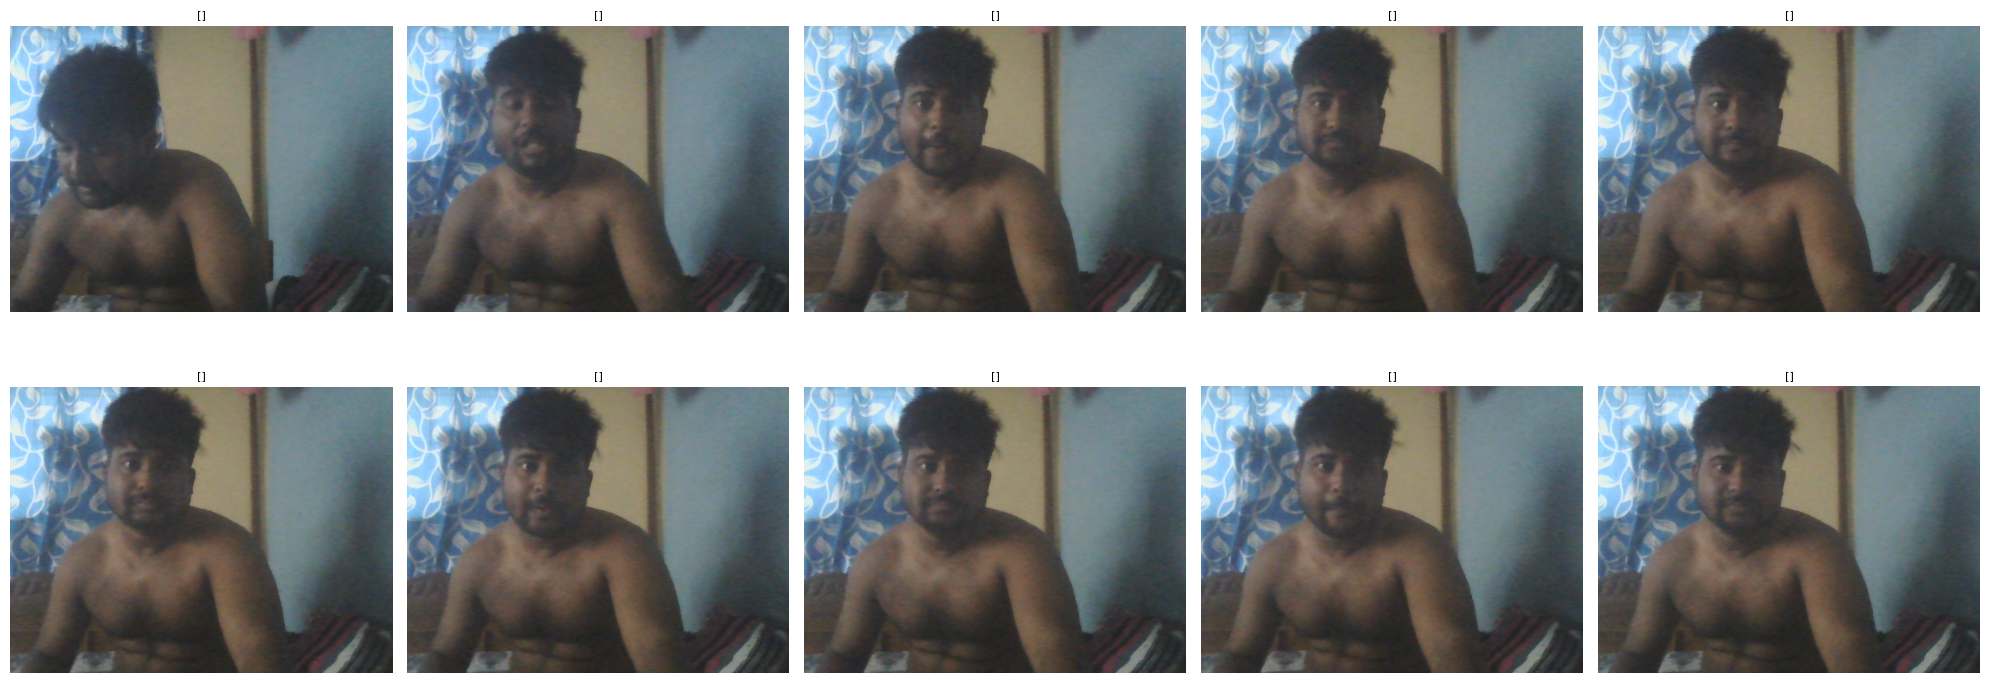


✅ Done!


In [43]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image as PILImage
import io, gc, time
import tensorflow as tf
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils

# Clear memory
try: del detect_fn
except: pass
gc.collect()
tf.keras.backend.clear_session()

# Load model
detect_fn      = tf.saved_model.load(os.path.join(paths['OUTPUT_PATH'], 'saved_model'))
category_index = label_map_util.create_category_index_from_labelmap(files['LABELMAP'])
print('✅ Model loaded!')

# Capture frames
cap = cv2.VideoCapture(0)
print('📸 Capturing 10 frames... show your hand gesture!')
time.sleep(2)  # 2 seconds to get ready

frames_results = []

for i in range(10):
    ret, frame = cap.read()
    if not ret: break

    image_np     = np.array(frame)
    input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, 0), dtype=tf.uint8)
    detections   = detect_fn(input_tensor)
    num_det      = int(detections.pop('num_detections'))
    detections   = {k: v[0, :num_det].numpy() for k, v in detections.items()}
    detections['num_detections']    = num_det
    detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

    image_with_boxes = image_np.copy()
    viz_utils.visualize_boxes_and_labels_on_image_array(
        image_with_boxes,
        detections['detection_boxes'],
        detections['detection_classes'],
        detections['detection_scores'],
        category_index,
        use_normalized_coordinates=True,
        max_boxes_to_draw=3,
        min_score_thresh=0.7,
        agnostic_mode=False)

    top = [(category_index.get(c, {}).get('name', str(c)), round(float(s), 2))
           for c, s in zip(detections['detection_classes'], detections['detection_scores'])
           if s >= 0.7]

    frames_results.append((cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB), top))
    print(f'  Frame {i+1}: {top if top else "Nothing detected"}')
    time.sleep(0.3)

cap.release()

# Show all frames in a grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for idx, (frame, top) in enumerate(frames_results):
    ax = axes[idx//5][idx%5]
    ax.imshow(frame)
    ax.set_title(str(top), fontsize=8)
    ax.axis('off')

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
display(PILImage.open(buf))
plt.close()
print('\n✅ Done!')